### 加载数据

In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split

# 42000个样本
# 第一列是目标值，y
# 第二列一直到最后是特征，相当于X，这些特征都是像素
# 手写数字图片，是由像素组成的，因此像素作为特征，决定着，这张图片是数字几
data = pd.read_csv('./digits.csv')
display(data.shape,data.head())

# 42000个样本有点多，取出其中5000个即可
index = np.random.randint(0,42000,size = 5000)
data = data.take(index)
display(data.shape,data.head())

FileNotFoundError: [Errno 2] No such file or directory: './digits.csv'

### 数据抽取与拆分

In [2]:
X = data.iloc[:,1:]
y = data['label']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=1024)

display(X_train.shape,y_train.shape)
display(X_test.shape,y_test.shape)
display(X_train.head())

(4500, 784)

(4500,)

(500, 784)

(500,)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
15512,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31657,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18353,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4394,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y_test.head()

38206    3
15873    5
28992    7
19651    0
28455    9
Name: label, dtype: int64

In [3]:
import matplotlib.pyplot as plt

In [6]:
28*28

784

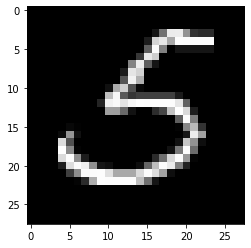

In [10]:
plt.imshow(X_test.iloc[1].values.reshape(28,28),cmap = 'gray')

In [11]:
plt.colormaps()

['Accent',
 'Accent_r',
 'Blues',
 'Blues_r',
 'BrBG',
 'BrBG_r',
 'BuGn',
 'BuGn_r',
 'BuPu',
 'BuPu_r',
 'CMRmap',
 'CMRmap_r',
 'Dark2',
 'Dark2_r',
 'GnBu',
 'GnBu_r',
 'Greens',
 'Greens_r',
 'Greys',
 'Greys_r',
 'OrRd',
 'OrRd_r',
 'Oranges',
 'Oranges_r',
 'PRGn',
 'PRGn_r',
 'Paired',
 'Paired_r',
 'Pastel1',
 'Pastel1_r',
 'Pastel2',
 'Pastel2_r',
 'PiYG',
 'PiYG_r',
 'PuBu',
 'PuBuGn',
 'PuBuGn_r',
 'PuBu_r',
 'PuOr',
 'PuOr_r',
 'PuRd',
 'PuRd_r',
 'Purples',
 'Purples_r',
 'RdBu',
 'RdBu_r',
 'RdGy',
 'RdGy_r',
 'RdPu',
 'RdPu_r',
 'RdYlBu',
 'RdYlBu_r',
 'RdYlGn',
 'RdYlGn_r',
 'Reds',
 'Reds_r',
 'Set1',
 'Set1_r',
 'Set2',
 'Set2_r',
 'Set3',
 'Set3_r',
 'Spectral',
 'Spectral_r',
 'Wistia',
 'Wistia_r',
 'YlGn',
 'YlGnBu',
 'YlGnBu_r',
 'YlGn_r',
 'YlOrBr',
 'YlOrBr_r',
 'YlOrRd',
 'YlOrRd_r',
 'afmhot',
 'afmhot_r',
 'autumn',
 'autumn_r',
 'binary',
 'binary_r',
 'bone',
 'bone_r',
 'brg',
 'brg_r',
 'bwr',
 'bwr_r',
 'cividis',
 'cividis_r',
 'cool',
 'cool_r',
 'co

### 模型训练与预测

In [12]:
%%time
model = LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
proba_ = model.predict_proba(X_test)
display('预测值类别是：',y_pred[:20])
display('预测值概率是：', proba_[:20])

'预测值类别是：'

array([3, 3, 7, 0, 0, 1, 7, 9, 6, 7, 7, 0, 0, 0, 6, 0, 0, 0, 5, 9],
      dtype=int64)

'预测值概率是：'

array([[3.70759304e-16, 1.83223966e-06, 2.07656315e-05, 9.98641115e-01,
        6.96326324e-21, 4.84723607e-05, 1.76736265e-16, 7.68791176e-42,
        1.28781442e-03, 5.08534278e-26],
       [7.73951780e-17, 1.90791645e-20, 9.46509210e-27, 9.99994320e-01,
        2.79429047e-30, 5.67950701e-06, 3.10151214e-20, 1.36195660e-38,
        4.84207233e-24, 5.09000368e-27],
       [2.47723925e-29, 4.94352114e-75, 3.00717744e-25, 1.25643257e-11,
        4.54798713e-45, 7.13189515e-41, 3.99046284e-46, 1.00000000e+00,
        1.73768729e-31, 1.67347662e-28],
       [1.00000000e+00, 3.07457121e-87, 8.25268701e-41, 1.45381587e-32,
        1.22330280e-42, 4.54580496e-21, 3.43766664e-57, 1.72557508e-42,
        4.04229554e-37, 1.04334902e-34],
       [9.65838485e-01, 1.18173213e-51, 1.72138047e-17, 2.28856782e-35,
        7.09812885e-37, 7.02933821e-15, 3.41615147e-02, 2.02685442e-26,
        4.66076814e-26, 1.09230593e-12],
       [4.18996256e-37, 1.00000000e+00, 1.07216535e-21, 5.85125570e-12,
   

Wall time: 14.4 s


In [13]:
model.score(X_test,y_test)

0.848

### 手动计算概率

In [14]:
w_ = model.coef_
b_ = model.intercept_
display(w_,w_.shape)
display(b_)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

(10, 784)

array([ -0.33007334,   3.69195333,   2.44963841,  -4.44596576,
        -0.89233096,  11.51836715,   1.85854711,   5.01194181,
       -14.83517455,  -4.0269032 ])

In [16]:
z = X_test.dot(w_.T) + b_

def softmax(z):
    return np.exp(z)/np.exp(z).sum(axis = 1).values.reshape(-1,1)

softmax(z)[:10]

,0,1,2,3,4,5,6,7,8,9
38206,3.707593e-16,1.832240e-06,2.076563e-05,9.986411e-01,6.963263e-21,4.847236e-05,1.767363e-16,7.687912e-42,1.287814e-03,5.085343e-26
15873,7.739518e-17,1.907916e-20,9.465092e-27,9.999943e-01,2.794290e-30,5.679507e-06,3.101512e-20,1.361957e-38,4.842072e-24,5.090004e-27
28992,2.477239e-29,4.943521e-75,3.007177e-25,1.256433e-11,4.547987e-45,7.131895e-41,3.990463e-46,1.000000e+00,1.737687e-31,1.673477e-28
19651,1.000000e+00,3.074571e-87,8.252687e-41,1.453816e-32,1.223303e-42,4.545805e-21,3.437667e-57,1.725575e-42,4.042296e-37,1.043349e-34
28455,9.658385e-01,1.181732e-51,1.721380e-17,2.288568e-35,7.098129e-37,7.029338e-15,3.416151e-02,2.026854e-26,4.660768e-26,1.092306e-12
3988,4.189963e-37,1.000000e+00,1.072165e-21,5.851256e-12,2.706966e-32,1.534075e-12,5.126024e-21,8.622802e-24,2.078485e-13,2.614249e-30
493,9.642511e-39,7.166413e-13,3.240366e-14,7.857497e-03,1.467851e-21,7.519559e-24,2.597862e-27,8.579757e-01,8.107035e-13,1.341668e-01
4471,4.933458e-30,6.295835e-57,2.960442e-47,1.093384e-18,1.479278e-08,1.119762e-26,2.018125e-39,1.793868e-04,4.382149e-13,9.998206e-01
26172,2.938104e-16,4.597218e-48,9.284792e-07,1.919149e-39,3.120217e-23,1.056353e-22,9.999991e-01,5.302777e-34,1.815266e-17,9.719032e-27
25007,1.081407e-31,5.660565e-35,3.506212e-17,8.093271e-19,1.882849e-15,4.181878e-28,8.530396e-32,1.000000e+00,1.128145e-13,4.208818e-09
